In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.pyplot import figure
from scipy.special import lambertw
from scipy.signal import hilbert
from tqdm import tqdm

In [2]:
# Gaussian profile for illustration
def gaussian(x,x0,sigma): return 1/(np.sqrt(2*np.pi)*sigma) * np.exp( - (x - x0)**2/(2*sigma**2))

def lorentzian(x,x0,fwhm): return 1/(1 + ( 2*(x-x0)/fwhm )**2)

### QNM data and dissipation frequencies

QNM frequency and decay rate data acquired from https://pages.jh.edu/eberti2/ringdown/ and stored in current/Berti_Schw/datafiles.txt

The dissipation spectrum is computed with a specified Bekenstein-Mukhanov quantisation parameter $\alpha$ for the quantum $\varpi_{BM} = c^3 \frac{\ln(\alpha)}{8 \pi G M}$. For every QNM frequency $\omega_{QNM}$ the set of dissipation frequencies is $\{ \omega_n = \omega_{QNM} - n \varpi_{BM}, n \in \mathbb N \}$ so that $\omega_n > 0$.

The various QNM are excited according to the $\textit{profile}$ coefficients. The power $P_{QNM}$ of the incident QNM particles is transferred to the dissipative particles $P_n$ as $P_n = \mathcal P(n) \cdot P_{QNM}$ where $\mathcal P(n)$ is the probability of the transition by $n$ levels modeled as $\mathcal P(n) = \frac{1}{Z}$ and $\mathcal P(n) = \frac{1}{Z} n^2$ where the normalisation $Z$ is fixed for every QNM so that $\sum _{n} \mathcal P(n) = 1 $.

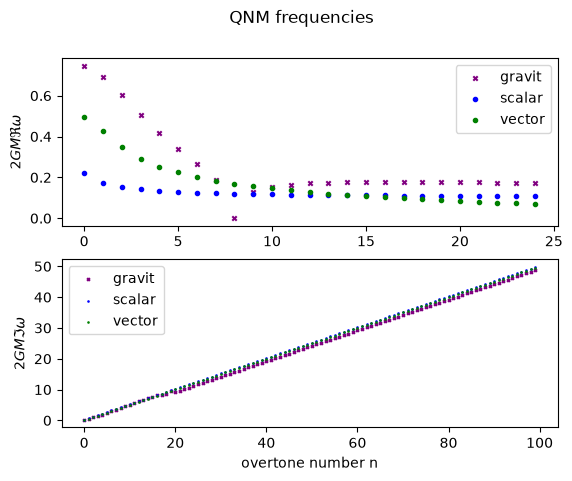

In [ ]:
# QNM data is in the form 2*G*mass*freq = Rs*freq

MwRe = {}
MwIm = {}
Err  = {}
Num  = {}

for i in range(3):

    f = open(f"Berti_Schw/s{i}l{i}.txt", "r")
    content = f.readlines()
    MwRe_ls, MwIm_ls, err_ls, num_ls = [],[],[],[]
    f.close()

    for line in content:
        MwRe_ls += [float(line.split()[0].replace(',', ''))]
        MwIm_ls += [float(line.split()[1].replace(',', ''))]
        err_ls += [float(line.split()[2].replace(',', ''))]
        num_ls += [float(line.split()[3].replace(',', ''))]

    MwRe[f"{i}"] = np.array(MwRe_ls)
    MwIm[f'{i}'] = np.array(MwIm_ls)
    Err[f'{i}']  = np.array(err_ls)
    Num[f'{i}']  = np.array(num_ls)

QNMdat = {}
QNMdat['MwRe'] = MwRe
QNMdat['MwIm'] = MwIm
QNMdat['Err'] = Err
QNMdat['Num'] = Num

fig, (ax1, ax2) = plt.subplots(2,1)
lim = 25
ax1.scatter(range(len(QNMdat['MwRe']['2'][:lim])),QNMdat['MwRe']['2'][:lim], marker = 'x', c = 'purple', s = 10, label = 'gravit')
ax1.scatter(range(len(QNMdat['MwRe']['0'][:lim])),QNMdat['MwRe']['0'][:lim], marker = '.', c = 'blue', label = 'scalar')
ax1.scatter(range(len(QNMdat['MwRe']['1'][:lim])),QNMdat['MwRe']['1'][:lim], marker = '.', c = 'green', label = 'vector')
ax1.legend()

lim = 100
ax2.scatter(range(len(QNMdat['MwIm']['2'][:lim])),QNMdat['MwIm']['2'][:lim], marker = 'x', c = 'purple', s = 4, label = 'gravit')
ax2.scatter(range(len(QNMdat['MwIm']['0'][:lim])),QNMdat['MwIm']['0'][:lim], marker = '.', c = 'blue', s = 3, label = 'scalar')
ax2.scatter(range(len(QNMdat['MwIm']['1'][:lim])),QNMdat['MwIm']['1'][:lim], marker = '.', c = 'green', s = 3,  label = 'vector')

ax2.set_xlabel('overtone number n')
ax1.set_ylabel(r'$2 G M \Re\omega $')
ax2.set_ylabel(r'$2 G M \Im\omega $')
fig.suptitle('QNM frequencies')
ax2.legend()
plt.savefig("images/QNM_freqs.png", dpi=150, bbox_inches='tight')

In [ ]:
# parameters and frequency calculation

M = 50* 1.989e30   # BH mass in kg, 1.989e30 is one solar mass
Rs = 2*M*6.67e-11/(3e8)**2
M_mP = M* 21.8e-9  # BH mass in Planck masses
Berti_to_Hz = 3e8/(2*np.pi*Rs)  # frequency conversion factor
dimless_to_Hz = 2*Berti_to_Hz

grav_freq = Berti_to_Hz*QNMdat['MwRe']['2']   # frequency in Hz 
grav_damp = Berti_to_Hz*QNMdat['MwIm']['2']

# employ a relative excitation profile for the various frequencies in grav_freq

profile = np.zeros(len(grav_freq))

# simple model: fundamental / first overtone / other overtones = 1 / 0.5 / 0.01

profile[0]=1
profile[1]=0.5
profile[2:]= [0.1*np.exp(-i) for i in range(len(grav_freq[2:]))]

alpha = 2      # Bekenstein-Mukhanov parameter
wBM = 3e8*np.log(alpha)/(8*(np.pi**2)*Rs)

max_transit = []
n = np.arange(0,15,1)

for gfreq in grav_freq:
    max_transit += [len(n[gfreq - n*wBM >= 0])]
    ls = gfreq - n*wBM

# Unnormalised probability profile for n transitions
def prob_expon(n, M_in_mP, alpha):  return np.exp( - np.log(alpha)*(n**2)/(16 * np.pi * M_in_mP**2) )
def prob_sq(n, M_in_mP, alpha): return n**2 * np.exp( - np.log(alpha)*(n**2)/(16 * np.pi * M_in_mP**2) )

# compute relative probability for max 15 step transitions
max_step = 15
step_size = np.linspace(1,max_step,max_step).astype(np.int32)

relprobs_expon = prob_expon(step_size, M_mP, alpha)
relprobs_expon *= 1/sum(relprobs_expon)

relprobs_sq = prob_sq(step_size, M_mP, alpha)
relprobs_sq *= 1/sum(relprobs_sq)

# create array of possible transitions (frequency of emission / damping rate / relative probability with expon or squared) for all QNM frequencies

emission = {'frequencies': np.array([]), 'damping': np.array([]) , 'probabilities_exp': np.array([]), 'probabilities_sq': np.array([])}

for i in range(len(grav_freq)):
    
    max_tr = max_transit[i]
    freq = grav_freq[i]
    
    mask = [s < max_tr for s in step_size]

    probs_exp =  relprobs_expon[mask] / sum(relprobs_expon[mask])
    probs_sq  =  relprobs_sq[mask] / sum(relprobs_expon[mask])
    damps = np.zeros_like(step_size) + grav_damp[i]

    emission['frequencies'] = np.append( emission['frequencies'], freq - step_size[mask]*wBM )
    emission['damping'] = np.append( emission['damping'], damps )
    emission['probabilities_exp'] = np.append( emission['probabilities_exp'], profile[i]*probs_exp )
    emission['probabilities_sq'] = np.append( emission['probabilities_sq'], profile[i]*probs_sq )

ind = np.argsort(emission['frequencies'])
emission['frequencies'] = emission['frequencies'][ind]
emission['damping'] = emission['damping'][ind]
emission['probabilities_exp'] = emission['probabilities_exp'][ind]
emission['probabilities_sq'] = emission['probabilities_sq'][ind]

print(grav_freq[0:10])

[2.42071390e+02 2.24605761e+02 1.95027965e+02 1.62929540e+02
 1.34431762e+02 1.09675267e+02 8.63233169e+01 6.01320150e+01
 1.49489885e-13 4.09832622e+01]


### QNMs and emitted radiation spectrum

In order to plot QNMs and the emission lines from the transition processes, we relate the signal amplitudes so that the total area of the QNM spectrum equals the total area of the emission spectrum (based on the principle of 1 graviton emitted for every 1 particle exciting the black hole). Because the spectral lines are all Lorentzian profiles with the same normalisation except for a rescaling corresponding to the excitation profile (for QNM) or the probability of occurence (for emissions) we demand that the equality holds in terms of the sums of these rescaling prefactors. 

These are encoded in $profile$ for the QNM lines and in $emission[probabilities\_exp/sq]$ for the emission lines.

Spacetime grey-body factors $T(\omega)$ are read from the file $transmission.npz$ as a function of the wavepacket frequency. This file is provided and can also be reproduced in the last block of this notebook by RK4 simulations of a wavepacket crossing the Zerilli potential barrier for a desired range of frequencies (takes some time to run). Transmission factors are then obtained from these data points by interpolation.

The spectrum is plotted by attenuating the power of the dissipation lines further, weighing them by the spacetime grey-body factor, resulting in the Lorentzian lines $T(\omega) \cdot Lor( \omega, \omega_n, \gamma_n)$.

In [ ]:
sum_QNM = sum(profile)
sum_emit_exp = sum(emission['probabilities_exp'])
sum_emit_sq  = sum(emission['probabilities_sq'])

ratio_exp = sum_QNM / sum_emit_exp
ratio_sq  = sum_QNM / sum_emit_sq

1.0001495070709283 1.4359438481944113


In [222]:
# plot spectral lines with chosen profile

def QNM_spectrum_curve( QNMfreqs , w , QNMdamps ):

    value_at_w = 0

    for i in range(len(QNMfreqs)):

        if i==8: continue
        freq = QNMfreqs[i]
        value_at_w += profile[i]*lorentzian( w, freq, QNMdamps[i] )

    return value_at_w

# spectrum curve function

def spectrum_curve( emission_dict , w , ptype ):

    value_at_w = 0

    freqs = emission_dict['frequencies']
    damps = emission_dict['damping']
    if ptype == 'exp':
        probs = emission_dict['probabilities_exp']
    if ptype == 'sq':
        probs = emission_dict['probabilities_sq']

    for i in range(len(emission_dict['frequencies'])):

        freq = freqs[i]
        prob = probs[i]
        damp = damps[i]
        value_at_w += prob*lorentzian(w, freq, 1e-2*damp)

    return value_at_w

def total_spectrum_curve( emission_dict, QNMfreqs, QNMdamps, w, ptype, norm_ratio ):

    value_at_w = 0

    value_at_w += QNM_spectrum_curve( QNMfreqs , w , 1e-2*QNMdamps ) 
    value_at_w += norm_ratio*spectrum_curve( emission_dict , w , ptype )

    return value_at_w

transm_data = np.load('transmission.npz')    # input from simulation result (QNM wavepacket)
freqs = transm_data["freq"] 
Ts = transm_data["transm"]

def transmission_interp(w_target, freq_range, T_factors):
    w_dimless = w_target / dimless_to_Hz
    return np.interp(w_dimless, freq_range, T_factors)

def grey_total_spectrum_curve( emission_dict, QNMfreqs, QNMdamps, w, ptype, norm_ratio ):

    value_at_w = 0

    value_at_w += QNM_spectrum_curve( QNMfreqs , w , 1e-2*QNMdamps ) 
    value_at_w += norm_ratio*spectrum_curve( emission_dict , w , ptype )*transmission_interp(w, freq_range=freqs, T_factors=Ts)

    return value_at_w

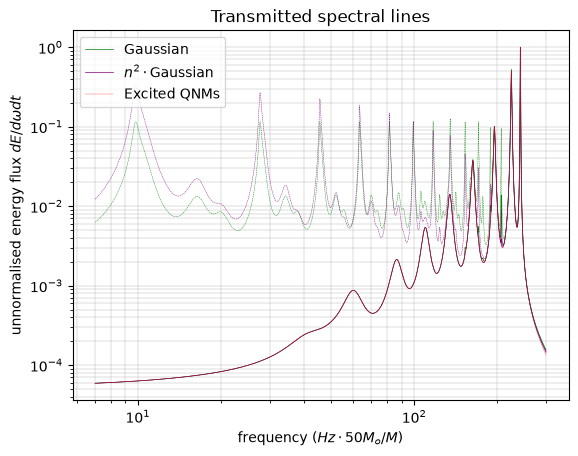

In [223]:
x = np.linspace(7,300,5000)

plt.loglog(x,grey_total_spectrum_curve( emission, grav_freq, grav_damp, x , ptype = 'exp', norm_ratio = ratio_exp ), linewidth = 0.5, label = 'Gaussian', c = 'green')
plt.loglog(x,grey_total_spectrum_curve( emission, grav_freq, grav_damp, x , ptype = 'sq', norm_ratio = ratio_sq ), linewidth = 0.5, label = r'$n^2 \cdot $Gaussian', c = 'purple')

plt.loglog(x,total_spectrum_curve( emission, grav_freq, grav_damp, x , ptype = 'exp', norm_ratio = ratio_exp ), linewidth = 0.3, c = 'green', ls = '--')
plt.loglog(x,total_spectrum_curve( emission, grav_freq, grav_damp, x , ptype = 'sq', norm_ratio = ratio_sq ), linewidth = 0.3, c = 'purple', ls = '--')

plt.loglog(x,QNM_spectrum_curve( grav_freq, x, 1e-2*grav_damp ), linewidth = 0.2, c = 'red', label = 'Excited QNMs')

plt.xlabel(rf'frequency $(Hz \cdot {int(M/1.989e30)} M_o/M)$')
plt.ylabel(r'unnormalised energy flux $dE/d\omega dt$')
plt.title('Transmitted spectral lines')
plt.grid(linewidth = 0.3, which="both")
plt.legend()

plt.savefig("images/grey_spectrum.png", dpi=300, bbox_inches='tight')

### Timescales for different BM quanta

Plot the decay timescale for the lowest dissipative frequency $\omega_{min}$ generated by the fundamental $n=0$ gravitational QNM ($l=s=2$) for a BH of mass $M = 50 M_\odot$, as a function pf the BM quantisation parameter $\alpha$.

By the approximate energy decay relation $E_j = E_0 e^{-T_{min}j}$ where $T_{min} = T(\omega_{min})$ we obtain the decay timescale $t_d = t_{roundtrip}/T_{min}$, with $t_{roundtrip} = 0.1 s$ being twice the time it takes a null signal to travel from a Planck-order distance from the horizon to the light ring in a $M = 50 M_\odot$ spacetime.

Important: make sure that the range of $T(\omega)$ data you use from $transmission.npz$ reach low enough values of $\omega$ to produce the following plots (existing file covers the range $10^{-4}$ to $1$ for the dimensionless $\omega$).

Smallest computed frequency and transmission: ω = 0.00012397654070387773, T = 6.087507568124186e-10 
 Smallest data points: ω = 0.0001, Τ = 6.08730409479629e-10


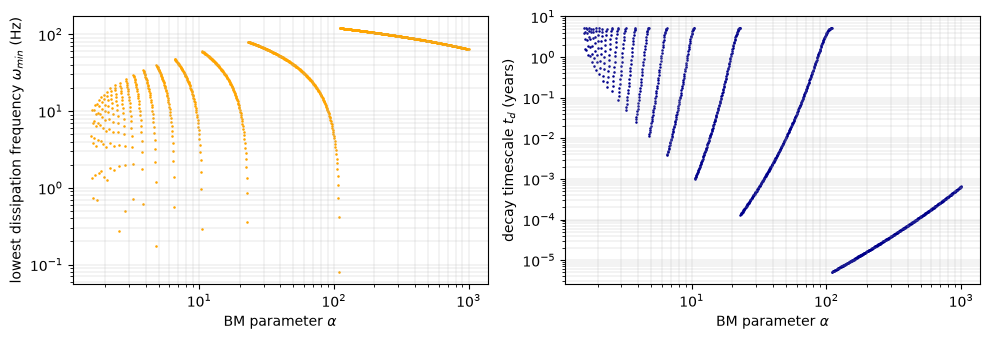

In [230]:
alpha_vals = np.logspace(0.2,3,1000)
wBM_vals = 3e8*np.log(alpha_vals)/(8*(np.pi**2)*Rs)
w0 = grav_freq[0]
n_transits = np.linspace(1,20,20)
t_round = 0.1 * 3.17e-8             # approx round-trip time for 50 solar masses in years

masks = [w0 - n_transits*wbm > 0 for wbm in wBM_vals]
max_transit_freqs = np.array( [ (w0 - n_transits*wBM_vals[i])[masks[i]][-1] for i in range(len(wBM_vals)) ] )

max_transit_transms = transmission_interp( max_transit_freqs, freq_range=freqs, T_factors=Ts )
dissipation_timescales = t_round / max_transit_transms

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,3.5))
ax1.scatter( alpha_vals , max_transit_freqs , s=0.7 , c = 'orange' )
ax1.set_yscale("log")
ax1.set_xscale("log")
ax1.set_xlabel(r"BM parameter $\alpha$")
ax1.set_ylabel(r"lowest dissipation frequency $\omega_{min}$ (Hz)")
ax1.grid(linewidth = 0.2, which="both")

ax2.scatter( alpha_vals , dissipation_timescales , s=0.7 , c = 'darkblue' )
ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_xlabel(r"BM parameter $\alpha$")
ax2.set_ylabel(r"decay timescale $t_d$ (years)")
ax2.grid(linewidth = 0.2, which="both")
#ax2.fill_between([1e-5,1e4], np.zeros_like([1e-5,1e4])+4, np.zeros_like([1e-5,1e4])+15, color = 'magenta', alpha = 0.3)
#ax2.set_ylim([3e-6, 11])
#ax2.set_xlim([0.8*alpha_vals[0],1.2*alpha_vals[-1]])

print(rf'Smallest computed frequency and transmission: ω = {min(max_transit_freqs)/dimless_to_Hz}, T = {transmission_interp( min(max_transit_freqs), freq_range=freqs, T_factors=Ts)}','\n', rf'Smallest data points: ω = {freqs[0]}, Τ = {Ts[0]}')

fig.tight_layout()
plt.savefig("images/timescales.png", dpi=200, bbox_inches='tight')

### Spacetime greybody factor

Use the following blocks to produce the file $transmission.npz$ containing the grey-body factor as a function of frequency $T(\omega)$ for a specified range of frequencies $\omega$.

The code solves the differential equation $-\partial^2 _t \psi(x,t) + \partial^2 _x \psi(x,t) + V_Z (x) \psi(x,t) = 0$ with the Zerilli potential $V_Z(x)$ with initial data consisting of a single right-moving wavepacket concentrated around a target frequency $\omega$ with variance $\sigma$ at position $x_0 \ll -1$. For every value of $\omega$ requested, the wavepacket is evolved until safely past the Zerilli barrier $x \gg 1$ and its amplitude is measured via a Hilbert transform to obtain the transmission $T = | A_{transm} |^2 / |A_{in}|^2$.

The quantities here are made dimensionless by $x = r_* / GM$ where $r_*$ is the tortoise variable. This is accompanied by the rescalings $\omega(x) = G M \omega(r_*)$ and $V_Z(x) = \frac{1}{(GM)^2} V_Z (r_*)$.


In [ ]:
# RK4 algorithm

def RK4(fx, fu, dt, t0, x0, u0, params): 

    f1 = fx(t0, x0, u0, params)
    g1 = fu(t0, x0, u0, params)
    f2 = fx(t0 + dt/2 , x0 + (dt/2)*f1, u0 + (dt/2)*g1, params)
    g2 = fu(t0 + dt/2 , x0 + (dt/2)*f1, u0 + (dt/2)*g1, params)
    f3 = fx(t0 + dt/2 , x0 + (dt/2)*f2, u0 + (dt/2)*g2, params)
    g3 = fu(t0 + dt/2 , x0 + (dt/2)*f2, u0 + (dt/2)*g2, params)
    f4 = fx(t0 + dt, x0 + dt*f3, u0 + dt*g3, params)
    g4 = fu(t0 + dt, x0 + dt*f3, u0 + dt*g3, params)

    x = x0 + (dt/6)*(f1 + 2*f2 + 2*f3 + f4)
    u = u0 + (dt/6)*(g1 + 2*g2 + 2*g3 + g4)

    return [x,u]

# Zerilli effective potential

def rstar_from_r(r,mass): return r + 2*mass*np.log(-1 + r/(2*mass))

def r_from_rstar(rstar,mass): return np.real(2*mass*(lambertw(np.exp(rstar/(2*mass) - 1)) + 1))

def Veff(rstar, mass=1, l=2):      # use with mass=1 in the dimensionless formulation
    
    r = r_from_rstar(rstar,mass)
    xi = 0.5*(l-1)*(l+2)
    
    return 2*(1 - 2*mass/r)*(9*(mass**3) + 3*(xi**2)*mass*(r**2) + (xi**2)*(1+xi)*(r**3) + 9*(mass**2)*xi*r)/((r**3)*(3*mass + xi*r)**2)

# RK4 systems of equations for -psi_tt + psi_xx + V(x) psi = 0

def fx(t, psi, dpsi, params): return dpsi

def fu(t, psi, dpsi, params): 
    
    dx = params['dx']
    loc = params['win_loc']
    return (-2*psi + np.roll(psi,1) + np.roll(psi,-1))/(dx**2) - Veff(loc,1,2)*psi

# sliding window simulation algorithm

def simul_sliding(fu, fx, u0, x0, tmin, params, direction):

    if direction == 'forward': v = 1
    elif direction == 'backward': v = -1
    else: 
        print('\n specify window direction')
        return 0

    dx, dt, N, n, win_loc = params.values()

    t = np.zeros(N)
    t[0] = tmin

    X = np.zeros((N,n), dtype=complex)
    U = np.zeros((N,n), dtype=complex)

    X[0,:] = x0
    U[0,:] = u0

    xin = x0
    uin = u0

    edge_thresh = 5

    for i in range(N-1):

        t[i+1] = t[i] + dt

        out = RK4(fx, fu, dt, t[i], xin, uin, params)
        xout = out[0]
        uout = out[1]

        X[i+1, :] = xout
        U[i+1, :] = uout

        xin = np.roll(xout,-v)
        uin = np.roll(uout,-v)

        xin[:edge_thresh] = 0
        xin[-edge_thresh:] = 0
        uin[:edge_thresh] = 0
        uin[-edge_thresh:] = 0

        win_loc += v*dx
        params['win_loc'] = win_loc

    end_params = {'win_loc' : win_loc}
    
    return X, U, t, end_params

<>:64: SyntaxWarning: invalid escape sequence '\o'
<>:64: SyntaxWarning: invalid escape sequence '\o'
C:\Users\konto\AppData\Local\Temp\ipykernel_22436\1114899353.py:64: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$G_N M \omega$')


starting position: r* = -250
 
dx = 0.10002000400078259, dt = 0.1, CFL = 1.000200040007826


100%|██████████| 260/260 [2:01:27<00:00, 28.03s/it]


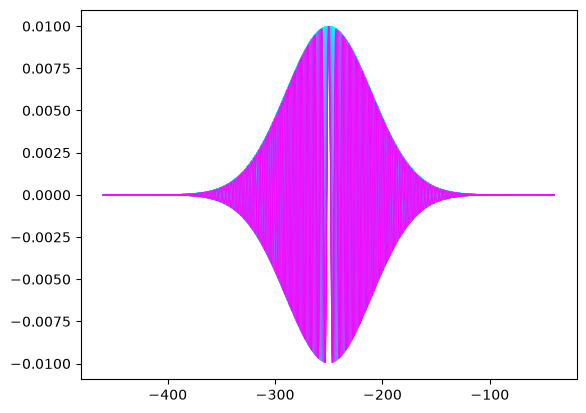

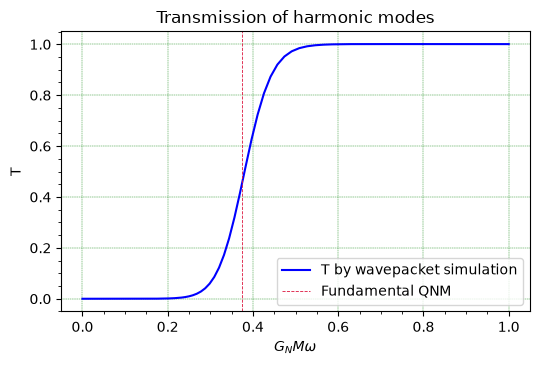

In [ ]:
# run to compute greybody factors by wavepacket simulations (takes a long time to run)
# alternatively use pre-existing file with 200 frequency values transmission.npz
# IMPORTANT: uncomment last line to save new data

freq_range = np.logspace(-4,0,260)

N = 5000
n = 4200
xsize = 500
direction = 'forward'
x_init = -250 

tmin, tmax = (0, xsize)
tsize = tmax-tmin

xmin = x_init - 0.5*(n/N)*xsize
xmax = xmin + xsize

x = np.linspace(xmin,xmax,N)
win_start = 0
win_loc = x[win_start : win_start+n].copy()

dx=x[1]-x[0]
dt=(tmax-tmin)/N
print(f'starting position: r* = {x_init}\n ')
print(f'dx = {dx}, dt = {dt}, CFL = {dx/dt}')

init_ampl = []
transm_ampl = []

for w_target in tqdm(freq_range):

    sig = 40
    psi_init = gaussian( win_loc , x_init , sig )*np.cos( w_target * (win_loc - x_init) )  # Gaussian at photosphere or custom location
    psi_der_init = w_target * np.sin( w_target * (win_loc - x_init) ) * gaussian( win_loc , x_init, sig ) + (0.5/sig**2)*(win_loc-x_init)*gaussian( win_loc , x_init, sig )*np.cos( w_target * (win_loc - x_init) ) 

    analytic = hilbert(np.real(psi_init))
    init_ampl += [np.max(np.abs(analytic))]

    params = {'dx' : dx,
        'dt' : dt,
        'N' : N,
        'n' : n,
        'win_loc' : win_loc.copy()}

    PSI, PSIDER, T, end_params = simul_sliding(fu, fx, psi_der_init, psi_init, tmin, params, direction)

    analytic = hilbert(np.real(PSI[-1,500:-500]))
    transm_ampl += [np.max(np.abs(analytic))]

T_factor = (np.array(transm_ampl)/np.array(init_ampl))**2

figure(figsize=(5.5, 3.75))
plt.plot(freq_range, T_factor, label = 'T by wavepacket simulation', c = 'blue')
plt.axvline(x=0.37365, ls = '--', linewidth = 0.6, c = 'crimson', label = 'Fundamental QNM')

plt.legend()
plt.title('Transmission of harmonic modes')
plt.grid(linestyle='--', c='green', linewidth=0.3)
plt.minorticks_on()
plt.xlabel(r'$G_N M \omega$')
plt.ylabel('T')
plt.tight_layout()
plt.savefig("images/transmission.png", dpi=150, bbox_inches='tight')

#np.savez("transmission.npz", freq=freq_range, transm = T_factor)